### Data Generation for frustrated lattices (Heisenberg J1-J2 models)
This notebook provides examples and tests for modules `spin_lattices` and `heisenberg_hamiltonians`.

In [1]:
# import black
# import jupyter_black

# jupyter_black.load(
#     lab=False,
#     line_length=79,
#     target_version=black.TargetVersion.PY39,
# )

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import lattice_symmetries as ls
import yaml
from heisenberg_hamiltonians import (
    make_unpacked_configurations,
    HeisenbergJ1J2,
)

from spin_lattices import (
    SpinLattice,
    ChainLattice,
    SquareLattice,
    KagomeLattice,
    TriangleLattice,
)

%matplotlib inline

2023-02-13 14:05:52.242 | DEBUG    | lattice_symmetries:__init__:49 - Initializing Haskell runtime...
2023-02-13 14:05:52.246 | DEBUG    | lattice_symmetries:__init__:51 - Initializing Chapel runtime...
[Debug]   [2023-02-13 14:05:52.273 | DEBUG    | lattice_symmetries:__init__:53 - Setting Python exception handler...
LOCALE0]   Initializing chpl_kernels ...
set_python_exception_handler ...


## Lattices

<AxesSubplot: xlabel='emb_x', ylabel='emb_y'>

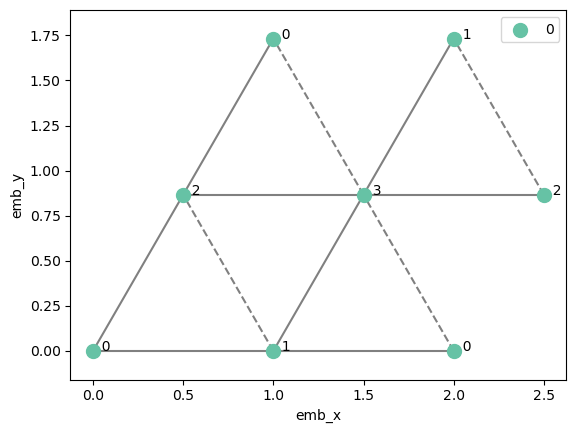

In [27]:
lat = TriangleLattice(width=2, height=2)
lat.plot() 

In [2]:
class OneDiagonalSquareLattice(SpinLattice):
    def __init__(self, width=1, height=1):
        r"""
        Generates square J1-J2 lattice with one diagonal
        (Should be equivalent to triangle lattice)

        The fundamental domain:

        ```
        C ----- D
        | \\    |
        |  \\   |
        |   \\  |
        |    \\ |
        A ----- B
        ```

        Size of the fundamentail domain is 1×1
        """
        u = np.array([1, 0])
        v = np.array([0, 1])

        named_sites = {
            "A": np.array([0, 0]),
            "B": np.array([1, 0]),
            "C": np.array([0, 1]),
            "D": np.array([1, 1]),
        }

        named_edges = [("AB", 1), ("AC", 1), ("CD", 1), ("BD", 1), ("CB", 2)]

        super().__init__(
            u=u,
            v=v,
            named_sites=named_sites,
            named_edges=named_edges,
            fundamental_domain_size=1,
            width=width,
            height=height,
        )

In [8]:
OneDiagonalSquareLattice(3, 3).number_spins

9

In [7]:
TriangleLattice(3, 3).number_spins

9

In [9]:
from heisenberg_hamiltonians import HeisenbergJ1J2

In [12]:
HeisenbergJ1J2(lattice=TriangleLattice(3, 3), use_symmetries=False, spin_inversion=None).hamiltonian.expression == HeisenbergJ1J2(lattice=OneDiagonalSquareLattice(3, 3), use_symmetries=False, spin_inversion=None).hamiltonian.expression

2023-02-13 14:10:56.396 | DEBUG    | heisenberg_hamiltonians:__init__:398 - number_spins=9
2023-02-13 14:10:56.398 | DEBUG    | heisenberg_hamiltonians:__init__:408 - Symmetry group contains 0 elements
[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...
2023-02-13 14:10:56.411 | DEBUG    | heisenberg_hamiltonians:__init__:417 - Hilbert space dimension is 126
2023-02-13 14:10:56.414 | DEBUG    | heisenberg_hamiltonians:__init__:398 - number_spins=9
2023-02-13 14:10:56.415 | DEBUG    | heisenberg_hamiltonians:__init__:408 - Symmetry group contains 0 elements
[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...
2023-02-13 14:10:56.433 | DEBUG    | heisenberg_hamiltonians:__init__:417 - Hilbert space dimension is 126


True

In [25]:
lat.as_igraph().degree(mode="out")

[6, 6, 6, 6]

#### Chain Lattice (1dim)

number_spins=12
Symmetry group contains 0 elements


[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...


Hilbert space dimension is 924


[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...


Calculating eigenvalues / eigenstates
Ground state energy is -21.5495636698


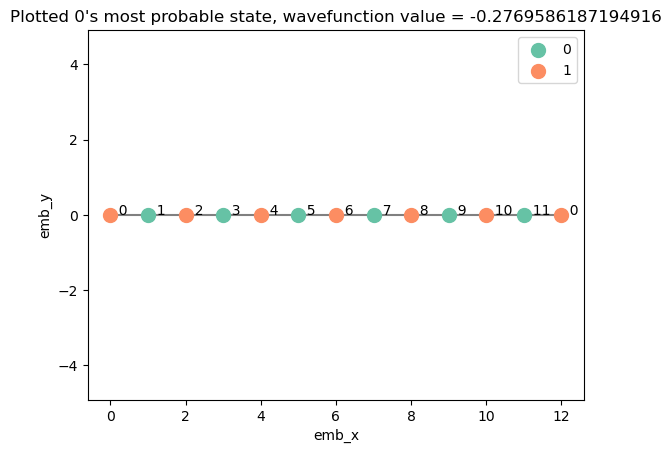

In [2]:
system_nosym = HeisenbergJ1J2(
    ChainLattice(width=12),
    J1=1,
    J2=0,
    use_symmetries=False,
    spin_inversion=None,
)
energy, state = system_nosym.get_eigenstates()
system_nosym.visualize_probable_configurations(m=0)

Antiferromagnetic, as expected

number_spins=12
Symmetry group contains 24 elements


[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...


Hilbert space dimension is 35
Calculating eigenvalues / eigenstates


[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...


Ground state energy is -21.5495636698


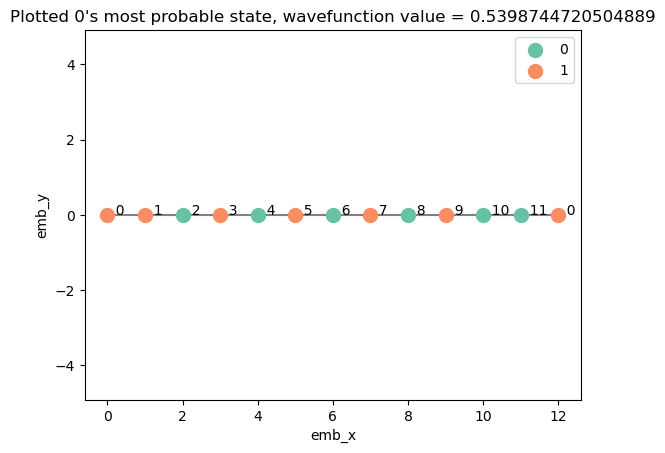

In [3]:
system_sym = HeisenbergJ1J2(
    ChainLattice(width=12), J1=1, J2=0, use_symmetries=True
)
energy, state = system_sym.get_eigenstates()
system_sym.visualize_probable_configurations(m=0, canonical_basis=False)

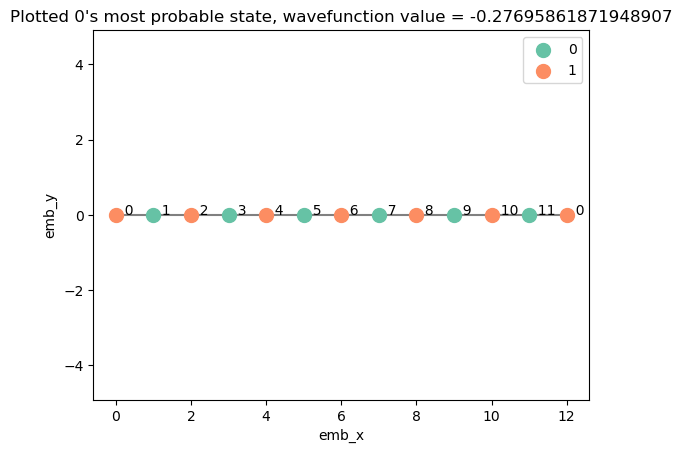

In [6]:
system_sym.visualize_probable_configurations(m=0, canonical_basis=True)

### Checks

#### 4×4 SquareLattice, J2=0

number_spins=16
Symmetry group contains 0 elements
Hilbert space dimension is 12870


[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...
[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...


Calculating eigenvalues / eigenstates
Ground state energy is -44.9139328337


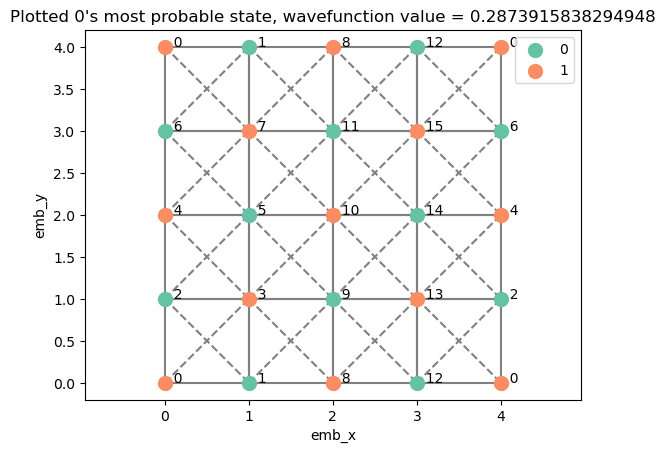

In [7]:
system_nosym = HeisenbergJ1J2(
    SquareLattice(width=4, height=4),
    J1=1,
    J2=0,
    use_symmetries=False,
    spin_inversion=None,
)
system_nosym.get_eigenstates()
system_nosym.visualize_probable_configurations(m=0)

The checkerboard, works as expected

number_spins=16
Symmetry group contains 128 elements


[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...


Hilbert space dimension is 107


[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...


Calculating eigenvalues / eigenstates
Ground state energy is -44.9139328337


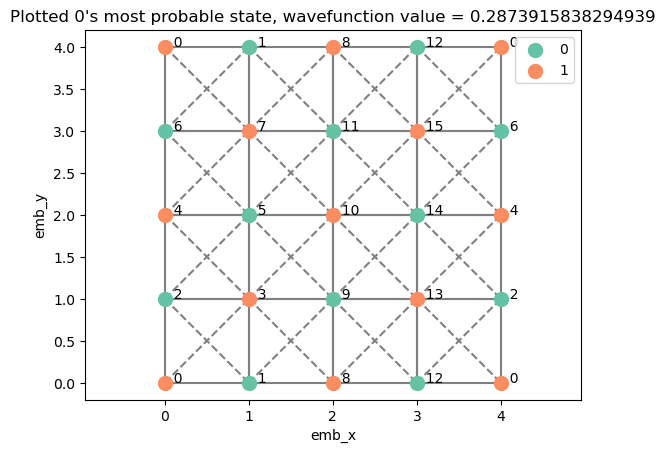

In [8]:
system_sym = HeisenbergJ1J2(
    SquareLattice(width=4, height=4), J1=1, J2=0, use_symmetries=True
)
system_sym.get_eigenstates()
system_sym.visualize_probable_configurations(m=0)

In [9]:
# with and without symmetries should give the same ground state energy
assert np.isclose(system_sym.ground_energy, system_nosym.ground_energy)

#### Reference 4×4

In [10]:
### FROM: https://github.com/twesterhout/nqs-playground/blob/0ba67c9d4ff9f70bbaeea2a9490271dd49ea5091/benchmark/benchmark_apply.py#L9-L20
def load_basis_and_hamiltonian(
    filename: str, no_symmetries=False, no_inversions=False
):
    import yaml

    # logger.info("Loading basis from '{}'...", filename)
    with open(filename, "r") as f:
        config = yaml.load(f, Loader=yaml.SafeLoader)
    if no_symmetries:
        config["basis"]["symmetries"] = []
    if no_inversions:
        del config["basis"]["spin_inversion"]
    basis = ls.SpinBasis.load_from_yaml(config["basis"])
    # logger.info("Loading Hamiltonian from '{}'...", filename)
    hamiltonian = ls.Operator.load_from_yaml(config["hamiltonian"], basis)
    return basis, hamiltonian


### END FROM

```
# Initial layout:
    # - permutation: [ 0,  1,  2,  3,
    #                  4,  5,  6,  7,
    #                  8,  9, 10, 11,
    #                 12, 13, 14, 15]
    #
```

In [11]:
# basis, hamiltonian = load_basis_and_hamiltonian(
#     "heisenberg_square_4x4.yaml", no_symmetries=True, no_inversions=True
# )
# eigenvalues, eigenstates = ls.diagonalize(hamiltonian, k=1)
# assert np.isclose(eigenvalues[0], system_nosym.ground_energy)
# # energy coincides with the reference implementation

#### 6×2 lattice 

number_spins=12
Symmetry group contains 0 elements
Hilbert space dimension is 462


[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...
[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...


Calculating eigenvalues / eigenstates
Ground state energy is -41.2913023078


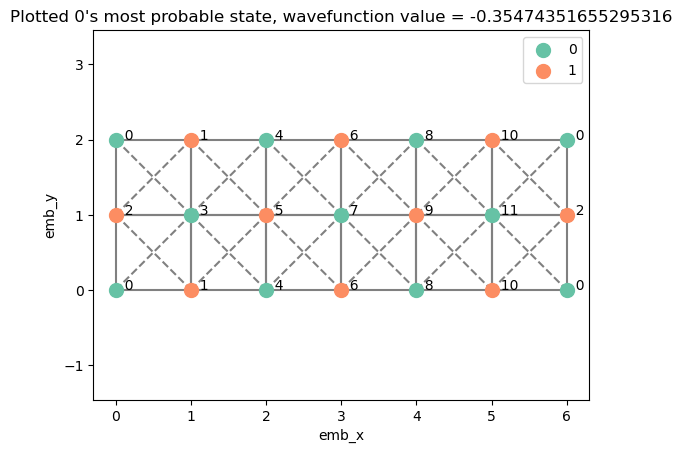

In [12]:
system_nosym = HeisenbergJ1J2(
    SquareLattice(width=6, height=2), J1=1, J2=0, use_symmetries=False
)
system_nosym.get_eigenstates()
system_nosym.visualize_probable_configurations(m=0)

The checkerboard, works as expected.

number_spins=12
Symmetry group contains 24 elements


[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...


Hilbert space dimension is 44
Calculating eigenvalues / eigenstates


[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...


Ground state energy is -41.2913023078


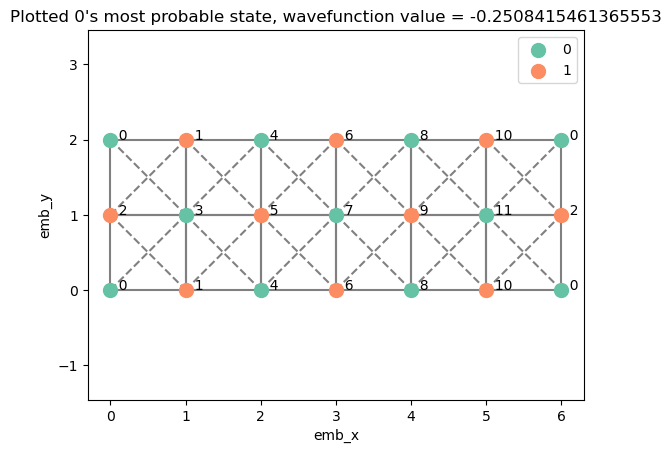

In [13]:
system_sym = HeisenbergJ1J2(
    SquareLattice(width=6, height=2), J1=1, J2=0, use_symmetries=True
)
system_sym.get_eigenstates()
system_sym.visualize_probable_configurations(m=0)

### Kagome Lattice

number_spins=24
Symmetry group contains 16 elements


[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...


Hilbert space dimension is 85662


[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...


Calculating eigenvalues / eigenstates
Ground state energy is -46.1341392314


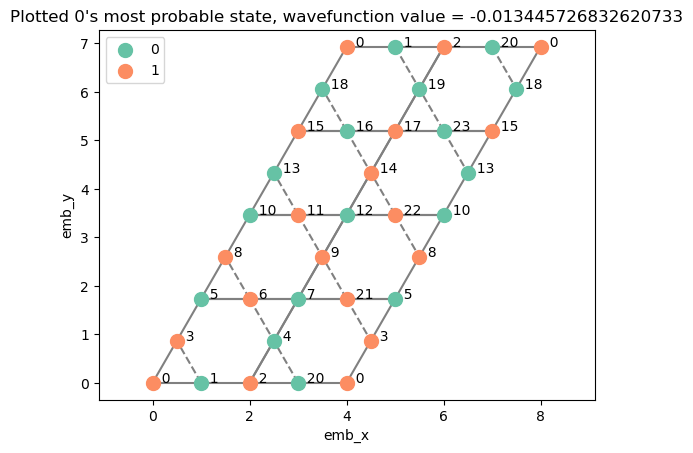

In [14]:
system = HeisenbergJ1J2(
    KagomeLattice(width=2, height=4), J1=1, J2=0, use_symmetries=True
)
system.get_eigenstates()
system.visualize_probable_configurations(m=0)

In [15]:
system.get_df_eigenstate(k=0, canonical_basis=True).sort_values("amplitude")

,eigenstate_coeff,amplitude
10420383,-2.616849e-08,2.616849e-08
13629444,-2.616849e-08,2.616849e-08
3965055,-2.616849e-08,2.616849e-08
12812160,-2.616849e-08,2.616849e-08
6295545,-2.616849e-08,2.616849e-08
...,...,...
12937893,-1.344573e-02,1.344573e-02
10310826,-1.344573e-02,1.344573e-02
3839322,-1.344573e-02,1.344573e-02
6474573,-1.344573e-02,1.344573e-02


number_spins=24
Symmetry group contains 16 elements


[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...


Hilbert space dimension is 85662


[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...


Using cached version of eigenvalues / eigenstates from groundstates/HeisenbergJ1J2-KagomeLattice2x4-1.0-0.0-True-1-1.pickle
Ground state energy is -46.1341392314


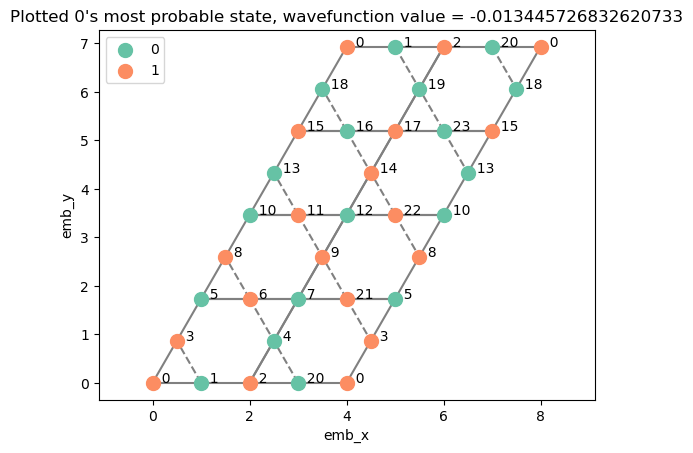

In [16]:
system = HeisenbergJ1J2(
    KagomeLattice(width=2, height=4), J1=1, J2=0, use_symmetries=True
)
system.get_eigenstates()
system.visualize_probable_configurations(m=0)

number_spins=18
Symmetry group contains 12 elements


[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...


Hilbert space dimension is 2102
Calculating eigenvalues / eigenstates


[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...


Ground state energy is -34.6339591099


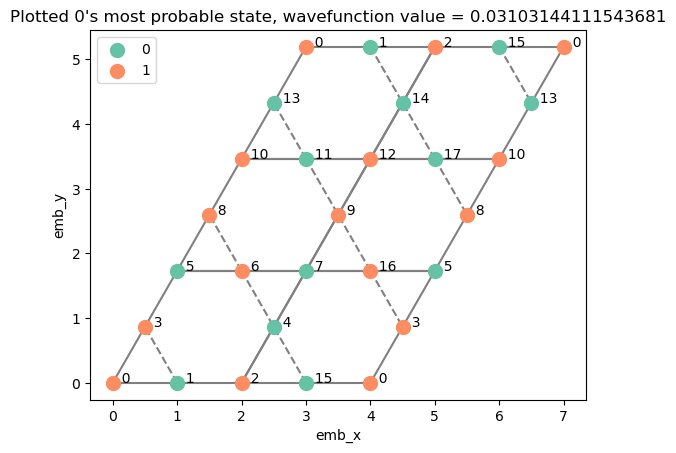

In [17]:
system = HeisenbergJ1J2(
    KagomeLattice(width=2, height=3), J1=1, J2=0, use_symmetries=True
)
system.get_eigenstates()
system.visualize_probable_configurations(m=0)

## Canonical basis

In [18]:
system = HeisenbergJ1J2(
    SquareLattice(width=4, height=4),
    J1=1,
    J2=0,
    use_symmetries=True,
    spin_inversion=1,
)
system.get_eigenstates()

system_nosym = HeisenbergJ1J2(
    SquareLattice(width=4, height=4),
    J1=1,
    J2=0,
    use_symmetries=False,
    spin_inversion=None,
)
system_nosym.get_eigenstates()

number_spins=16
Symmetry group contains 128 elements


[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...


Hilbert space dimension is 107


[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...
[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...


Using cached version of eigenvalues / eigenstates from groundstates/HeisenbergJ1J2-SquareLattice4x4-1.0-0.0-True-1-1.pickle
Ground state energy is -44.9139328337
number_spins=16
Symmetry group contains 0 elements
Hilbert space dimension is 12870
Using cached version of eigenvalues / eigenstates from groundstates/HeisenbergJ1J2-SquareLattice4x4-1.0-0.0-False-None-1.pickle
Ground state energy is -44.9139328337


[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...


(array([-44.91393283]),
 array([[ 0.00075158],
        [ 0.00134471],
        [-0.00087267],
        ...,
        [-0.00087267],
        [ 0.00134471],
        [ 0.00075158]]))

Now we compare the results of the diagonalization in the full basis with the restored ground state obtained from the basis where symmetries are taken into account. Note that the ground state is an eigenvector, so it is defined up to multiplication by a constant. We normalize it and make sure it's real, but the constant still can be either 1 or -1. So to check whether two ground states coincide, we first make first element to have the same sign by multiplying one of the vectors on -1 when necessary.

In [19]:
system_nosym.get_df_ground_state()

,eigenstate_coeff,amplitude
255,0.000752,0.000752
383,0.001345,0.001345
447,-0.000873,0.000873
479,-0.000873,0.000873
495,0.000694,0.000694
...,...,...
65040,0.000694,0.000694
65056,-0.000873,0.000873
65088,-0.000873,0.000873
65152,0.001345,0.001345


In [20]:
system.get_df_ground_state(canonical_basis=True)

,eigenstate_coeff,amplitude
255,0.000752,0.000752
383,0.001345,0.001345
447,-0.000873,0.000873
479,-0.000873,0.000873
495,0.000694,0.000694
...,...,...
65040,0.000694,0.000694
65056,-0.000873,0.000873
65088,-0.000873,0.000873
65152,0.001345,0.001345


In [21]:
system_nosym.get_df_ground_state()

,eigenstate_coeff,amplitude
255,0.000752,0.000752
383,0.001345,0.001345
447,-0.000873,0.000873
479,-0.000873,0.000873
495,0.000694,0.000694
...,...,...
65040,0.000694,0.000694
65056,-0.000873,0.000873
65088,-0.000873,0.000873
65152,0.001345,0.001345


In [22]:
(
    system_nosym.get_df_ground_state()
    .join(
        system.get_df_ground_state(canonical_basis=True),
        how="outer",
        lsuffix="_x",
        rsuffix="_y",
    )
    .assign(
        ok=lambda x: np.isclose(
            x["eigenstate_coeff_x"],
            x["eigenstate_coeff_y"]
            * np.sign(x["eigenstate_coeff_y"].iloc[0])
            * np.sign(x["eigenstate_coeff_x"].iloc[0]),
        )
    )
)

,eigenstate_coeff_x,amplitude_x,eigenstate_coeff_y,amplitude_y,ok
255,0.000752,0.000752,0.000752,0.000752,True
383,0.001345,0.001345,0.001345,0.001345,True
447,-0.000873,0.000873,-0.000873,0.000873,True
479,-0.000873,0.000873,-0.000873,0.000873,True
495,0.000694,0.000694,0.000694,0.000694,True
...,...,...,...,...,...
65040,0.000694,0.000694,0.000694,0.000694,True
65056,-0.000873,0.000873,-0.000873,0.000873,True
65088,-0.000873,0.000873,-0.000873,0.000873,True
65152,0.001345,0.001345,0.001345,0.001345,True


In [23]:
assert (
    system_nosym.get_df_ground_state()
    .join(
        system.get_df_ground_state(canonical_basis=True),
        how="outer",
        lsuffix="_x",
        rsuffix="_y",
    )
    .assign(
        ok=lambda x: np.isclose(
            x["eigenstate_coeff_x"],
            x["eigenstate_coeff_y"]
            * np.sign(x["eigenstate_coeff_y"].iloc[0])
            * np.sign(x["eigenstate_coeff_x"].iloc[0]),
        )
    )["ok"]
    .all()
)

Order of elements in the dataframe correponds to order of elements in basis.states

In [24]:
assert (
    system.get_df_ground_state(canonical_basis=True).index
    == system.canonical_basis.states
).all()

In [25]:
assert (
    system.get_df_ground_state(canonical_basis=False).index
    == system.basis.states
).all()

In [28]:
system_sym.hamiltonian.expression.replace_indices()

'{"expression":"1.0 × σᶻ₀ σᶻ₁ + 1.0 × σᶻ₀ σᶻ₁₁ + 2.0 × σ⁺₀ σ⁻₁ + 2.0 × σ⁺₀ σ⁻₁₁ + 2.0 × σ⁻₀ σ⁺₁ + 2.0 × σ⁻₀ σ⁺₁₁ + 1.0 × σᶻ₁ σᶻ₂ + 2.0 × σ⁺₁ σ⁻₂ + 2.0 × σ⁻₁ σ⁺₂ + 1.0 × σᶻ₂ σᶻ₃ + 2.0 × σ⁺₂ σ⁻₃ + 2.0 × σ⁻₂ σ⁺₃ + 1.0 × σᶻ₃ σᶻ₄ + 2.0 × σ⁺₃ σ⁻₄ + 2.0 × σ⁻₃ σ⁺₄ + 1.0 × σᶻ₄ σᶻ₅ + 2.0 × σ⁺₄ σ⁻₅ + 2.0 × σ⁻₄ σ⁺₅ + 1.0 × σᶻ₅ σᶻ₆ + 2.0 × σ⁺₅ σ⁻₆ + 2.0 × σ⁻₅ σ⁺₆ + 1.0 × σᶻ₆ σᶻ₇ + 2.0 × σ⁺₆ σ⁻₇ + 2.0 × σ⁻₆ σ⁺₇ + 1.0 × σᶻ₇ σᶻ₈ + 2.0 × σ⁺₇ σ⁻₈ + 2.0 × σ⁻₇ σ⁺₈ + 1.0 × σᶻ₈ σᶻ₉ + 2.0 × σ⁺₈ σ⁻₉ + 2.0 × σ⁻₈ σ⁺₉ + 1.0 × σᶻ₉ σᶻ₁₀ + 2.0 × σ⁺₉ σ⁻₁₀ + 2.0 × σ⁻₉ σ⁺₁₀ + 1.0 × σᶻ₁₀ σᶻ₁₁ + 2.0 × σ⁺₁₀ σ⁻₁₁ + 2.0 × σ⁻₁₀ σ⁺₁₁","particle":"spin-1/2"}'

In [35]:
system.symmerties.generators[3].permutation

array([ 0,  2, 12, 13,  8,  9,  1,  3,  4, 14, 10,  5,  6, 15, 11,  7],
      dtype=int32)

In [36]:
system.get_df_ground_state(unpack_configurations=True, canonical_basis=True).sort_values("amplitude", ascending=False).iloc[0]["configuration"]

array([1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 1, 0, 0, 1, 0, 1], dtype=uint64)

In [38]:
system.lat.kind_to_edges[1]

[(0, 1),
 (0, 2),
 (2, 3),
 (1, 3),
 (2, 4),
 (4, 5),
 (3, 5),
 (4, 6),
 (6, 7),
 (5, 7),
 (6, 0),
 (7, 1),
 (1, 8),
 (3, 9),
 (8, 9),
 (5, 10),
 (9, 10),
 (7, 11),
 (10, 11),
 (11, 8),
 (8, 12),
 (9, 13),
 (12, 13),
 (10, 14),
 (13, 14),
 (11, 15),
 (14, 15),
 (15, 12),
 (12, 0),
 (13, 2),
 (14, 4),
 (15, 6)]